# Extension Module E2 — Spectral / Graph Clustering (Tutorial Pipeline)

**Project:** USL — Hotel Booking Unsupervised Learning
**Module:** E2 Spectral Clustering (Extension)
**Authors:** 72922, 72898, 60253

---

## Motivation

K-Means and GMM assume convex, roughly spherical cluster geometry in the ambient 47-dimensional
Euclidean space.  Spectral clustering relaxes this assumption by working with the **graph
Laplacian** of a similarity graph built on the data.

### Tutorial pipeline

Following `Tutorial_SpectralClustering.ipynb` (course material), this notebook implements
spectral clustering **from scratch**:

1. **RBF-weighted kNN affinity** — weight $w_{ij} = \exp(-\|x_i - x_j\|^2 / 2\sigma^2)$
   for the $k$ nearest neighbours of each point; $\sigma$ estimated automatically from the
   data (median pairwise distance heuristic).
2. **Explicit $W$, $D$, $L_{\text{sym}}$** construction: $L_{\text{sym}} = I - D^{-1/2} W D^{-1/2}$.
3. **Dense `np.linalg.eigh`** — stable, no ARPACK convergence issues.
4. **Row-normalised spectral embedding** (Ng–Jordan–Weiss formulation).
5. **From-scratch Lloyd's $k$-means** in the embedding space.

### Computational constraints

Full graph construction on 119 192 samples is $O(n^2)$ in memory (~54 GB for float64).
A **stratified subsample of $n = 10\,000$** (seed 42, stratified by K-Means $k=8$ labels)
is drawn first; the dense spectral computation then uses a further random
**sub-subsample of $n = 3\,000$** (72 MB pairwise matrix, eigh feasible in seconds).

## 0. Setup and helper functions

In [1]:
import os, warnings, time, itertools
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score,
    davies_bouldin_score, adjusted_rand_score,
)

# Single-thread numerical libraries (mirrors tutorial)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Tutorial helper functions ─────────────────────────────────────────────
# Adapted verbatim from Tutorial_SpectralClustering.ipynb (course material).

def pairwise_squared_distances(X):
    """Dense pairwise squared Euclidean distances (O(n^2 d))."""
    X = np.asarray(X, dtype=float)
    sq = np.sum(X ** 2, axis=1, keepdims=True)
    return np.maximum(sq + sq.T - 2.0 * (X @ X.T), 0.0)

def estimate_sigma_from_distances(dist2):
    """sqrt of median non-zero off-diagonal squared distance (data-driven sigma)."""
    upper = dist2[np.triu_indices_from(dist2, k=1)]
    upper = upper[upper > 0]
    return float(np.sqrt(np.median(upper))) if len(upper) else 1.0

def knn_affinity_from_points(X, n_neighbors=10, sigma=None, mutual=False):
    """
    Symmetric kNN affinity matrix with RBF weights.

    w_ij = exp(-||xi - xj||^2 / (2 sigma^2))  for the n_neighbors closest j.
    Symmetrised by union (mutual=False, sklearn default) or
    intersection (mutual=True, stricter).
    sigma is estimated from data if None.
    """
    dist2 = pairwise_squared_distances(X)
    n = dist2.shape[0]
    if sigma is None:
        sigma = estimate_sigma_from_distances(dist2)
    work = dist2.copy()
    np.fill_diagonal(work, np.inf)
    knn_idx = np.argsort(work, axis=1)[:, :n_neighbors]
    W = np.zeros((n, n), dtype=float)
    for i in range(n):
        js = knn_idx[i]
        W[i, js] = np.exp(-dist2[i, js] / (2.0 * sigma ** 2))
    if mutual:
        mask = (W > 0) & (W.T > 0)
        W = np.where(mask, np.maximum(W, W.T), 0.0)
    else:
        W = np.maximum(W, W.T)          # union
    np.fill_diagonal(W, 0.0)
    return W, sigma

def sorted_eigenpairs(L):
    """Eigendecomposition of a symmetric matrix — ascending order, dense eigh."""
    evals, evecs = np.linalg.eigh(L)
    order = np.argsort(evals)
    return evals[order], evecs[:, order]

def build_normalised_laplacian(W):
    """
    L_sym = I - D^{-1/2} W D^{-1/2}   (Ng-Jordan-Weiss normalised Laplacian).
    Returns (L_sym [n x n], degrees [n]).
    """
    degrees = W.sum(axis=1)
    safe_d  = np.where(degrees > 0, degrees, 1.0)
    d_inv_sqrt = 1.0 / np.sqrt(safe_d)
    L_sym = np.eye(len(W)) - (d_inv_sqrt[:, None] * W * d_inv_sqrt[None, :])
    return L_sym, degrees

def spectral_embedding_from_laplacian(L_sym, k, row_normalize=True):
    """
    First k eigenvectors of L_sym (dense eigh), optionally row-normalised (NJW).
    Returns (all_eigenvalues [n], U [n x k], T [n x k]).
    """
    evals, evecs = sorted_eigenpairs(L_sym)
    U = evecs[:, :k]
    if not row_normalize:
        return evals, U, U
    norms = np.linalg.norm(U, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return evals, U, U / norms

def lloyd_kmeans(X, n_clusters, n_init=20, max_iter=200, tol=1e-6, random_state=42):
    """From-scratch Lloyd's k-means (mirrors tutorial implementation)."""
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    rng_loc = np.random.default_rng(random_state)
    best_labels = best_centers = None
    best_inertia = np.inf
    for _ in range(n_init):
        idx0 = rng_loc.choice(len(X), size=n_clusters, replace=False)
        centers = X[idx0].copy()
        for _ in range(max_iter):
            d2 = ((X[:, None] - centers[None]) ** 2).sum(axis=2)
            labels = np.argmin(d2, axis=1)
            new_c = centers.copy()
            for j in range(n_clusters):
                m = X[labels == j]
                new_c[j] = m.mean(axis=0) if len(m) else X[rng_loc.integers(len(X))]
            shift = float(np.linalg.norm(new_c - centers))
            centers = new_c
            if shift <= tol:
                break
        d2 = ((X[:, None] - centers[None]) ** 2).sum(axis=2)
        labels = np.argmin(d2, axis=1)
        inertia = float(d2[np.arange(len(X)), labels].sum())
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centers = centers.copy()
    return best_labels, best_centers, best_inertia

print("Tutorial helper functions loaded:")
print("  pairwise_squared_distances, estimate_sigma_from_distances")
print("  knn_affinity_from_points, sorted_eigenpairs")
print("  build_normalised_laplacian, spectral_embedding_from_laplacian")
print("  lloyd_kmeans")
print(f"NumPy {np.__version__}  |  Pandas {pd.__version__}")

Tutorial helper functions loaded:
  pairwise_squared_distances, estimate_sigma_from_distances
  knn_affinity_from_points, sorted_eigenpairs
  build_normalised_laplacian, spectral_embedding_from_laplacian
  lloyd_kmeans
NumPy 2.4.6  |  Pandas 3.0.3


In [2]:
# Flexible path detection (works from src/, tables/, or project root)
_cwd = Path('.').resolve()
TABLES_DIR = _cwd.parent / 'tables'
FIGURES_DIR = _cwd.parent / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"TABLES_DIR  : {TABLES_DIR.resolve()}")
print(f"FIGURES_DIR : {FIGURES_DIR.resolve()}")

TABLES_DIR  : /home/xera/school/USL/usl_project1_72922_72898_60253/tables
FIGURES_DIR : /home/xera/school/USL/usl_project1_72922_72898_60253/figures


In [3]:
# ── Subsampling ────────────────────────────────────────────────────────────
N_SUB   = 10_000   # stratified subsample (context / comparability)
N_DENSE =  3_000   # sub-subsample for dense spectral computation
SUB_SEED = 42

# ── Graph / Laplacian ──────────────────────────────────────────────────────
K_GRAPH_DEFAULT = 15
K_GRAPH_SWEEP   = [10, 15, 20]
MUTUAL_KNN      = False   # union symmetrisation (sklearn default)

# ── Eigenvectors / clustering ──────────────────────────────────────────────
N_EIGEN_SHOW = 12
K_RANGE      = [3, 4, 5, 6, 7, 8]
SC_SEEDS     = [7, 42, 123]
KMEANS_K     = 8
KMEANS_SEED  = 42

print("Constants ready.")
print(f"  Stratified subsample  : n = {N_SUB:,}  (seed {SUB_SEED})")
print(f"  Dense computation on  : n = {N_DENSE:,}  "
      f"(pairwise matrix = {N_DENSE**2*8/1e6:.0f} MB)")
print(f"  k_graph sweep         : {K_GRAPH_SWEEP}  mutual={MUTUAL_KNN}")
print(f"  Clustering sweep k    : {K_RANGE}")
print(f"  Seeds                 : {SC_SEEDS}")

Constants ready.
  Stratified subsample  : n = 10,000  (seed 42)
  Dense computation on  : n = 3,000  (pairwise matrix = 72 MB)
  k_graph sweep         : [10, 15, 20]  mutual=False
  Clustering sweep k    : [3, 4, 5, 6, 7, 8]
  Seeds                 : [7, 42, 123]


## 1. Load preprocessed data

In [4]:
matrix_path = TABLES_DIR / 'final_precluster_matrix.csv'
print(f"Loading: {matrix_path.resolve()}")
t0 = time.time()
X_prepared = pd.read_csv(matrix_path).values
print(f"  Shape: {X_prepared.shape}  |  dtype: {X_prepared.dtype}")
print(f"  NaN count: {np.isnan(X_prepared).sum()}")
print(f"  Loaded in {time.time()-t0:.1f}s")

Loading: /home/xera/school/USL/usl_project1_72922_72898_60253/tables/final_precluster_matrix.csv


  Shape: (119192, 47)  |  dtype: float64
  NaN count: 0
  Loaded in 0.2s


## 2. Reference K-Means labels and stratified subsamples

**Step 1** — Refit K-Means $k=8$ on the full 119 192 × 47 matrix to obtain
reference labels for stratified sampling.

**Step 2** — Draw a stratified subsample $n=10\,000$ (`X_sub`), preserving
cluster proportions.

**Step 3** — Draw a random sub-subsample $n=3\,000$ (`X_dense`) from `X_sub`
for the dense $O(n^2)$ spectral computation.

In [5]:
print(f"Fitting reference KMeans(k={KMEANS_K}, seed={KMEANS_SEED}) on full data...")
t0 = time.time()
km_ref = KMeans(n_clusters=KMEANS_K, n_init=20, max_iter=300, random_state=KMEANS_SEED)
km_ref.fit(X_prepared)
km_full = km_ref.labels_
print(f"  Done in {time.time()-t0:.1f}s")

# Stratified subsample (N_SUB from full data)
rng = np.random.default_rng(SUB_SEED)
sub_idx = []
for c in range(KMEANS_K):
    c_idx = np.where(km_full == c)[0]
    n_c = max(1, round(N_SUB * len(c_idx) / len(km_full)))
    sub_idx.extend(rng.choice(c_idx, size=min(n_c, len(c_idx)), replace=False).tolist())
sub_idx = np.array(sub_idx)
if len(sub_idx) > N_SUB:
    sub_idx = rng.choice(sub_idx, size=N_SUB, replace=False)
elif len(sub_idx) < N_SUB:
    extra = rng.choice(np.arange(len(X_prepared)),
                       size=N_SUB - len(sub_idx), replace=False)
    sub_idx = np.concatenate([sub_idx, extra])
sub_idx = np.sort(sub_idx)
X_sub = X_prepared[sub_idx]
km_sub = km_full[sub_idx]

print(f"\nStratified subsample X_sub: {X_sub.shape}")
for c in range(KMEANS_K):
    n_c = (km_sub == c).sum()
    print(f"  Cluster {c}: {n_c:5d} ({n_c/N_SUB*100:.1f}%)")

Fitting reference KMeans(k=8, seed=42) on full data...


  Done in 3.7s

Stratified subsample X_sub: (10000, 47)
  Cluster 0:   332 (3.3%)
  Cluster 1:  2220 (22.2%)
  Cluster 2:   528 (5.3%)
  Cluster 3:  1571 (15.7%)
  Cluster 4:   691 (6.9%)
  Cluster 5:  3162 (31.6%)
  Cluster 6:  1044 (10.4%)
  Cluster 7:   452 (4.5%)


In [6]:
# Dense sub-subsample for O(n^2) computation
rng2 = np.random.default_rng(SUB_SEED + 1)
dense_local_idx = np.sort(rng2.choice(len(X_sub), size=N_DENSE, replace=False))
X_dense = X_sub[dense_local_idx]
km_dense = km_sub[dense_local_idx]

print(f"Dense sub-subsample X_dense: {X_dense.shape}")
print(f"  Pairwise distance matrix : {N_DENSE}x{N_DENSE} x 8 bytes "
      f"= {N_DENSE**2*8/1e6:.0f} MB")
print(f"  KMeans cluster distribution:")
for c in range(KMEANS_K):
    n_c = (km_dense == c).sum()
    print(f"    Cluster {c}: {n_c:4d} ({n_c/N_DENSE*100:.1f}%)")

Dense sub-subsample X_dense: (3000, 47)
  Pairwise distance matrix : 3000x3000 x 8 bytes = 72 MB
  KMeans cluster distribution:
    Cluster 0:  102 (3.4%)
    Cluster 1:  653 (21.8%)
    Cluster 2:  158 (5.3%)
    Cluster 3:  481 (16.0%)
    Cluster 4:  210 (7.0%)
    Cluster 5:  956 (31.9%)
    Cluster 6:  290 (9.7%)
    Cluster 7:  150 (5.0%)


## 3. Affinity graph and normalised Laplacian

We build the **RBF-weighted kNN affinity matrix** following the tutorial:

$$w_{ij} = \exp\!\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)
\quad \text{for } j \in \text{kNN}(i)$$

$\sigma$ is estimated automatically as $\sqrt{\text{median}_{i<j}\{\|x_i-x_j\|^2\}}$
(data-driven, robust to scale).

The **normalised symmetric Laplacian** is then:
$$L_{\text{sym}} = I - D^{-1/2} W D^{-1/2}$$

In [7]:
print(f"Building RBF-weighted kNN affinity "
      f"(k_graph={K_GRAPH_DEFAULT}, mutual={MUTUAL_KNN})...")
t0 = time.time()
W_main, sigma_main = knn_affinity_from_points(
    X_dense, n_neighbors=K_GRAPH_DEFAULT, sigma=None, mutual=MUTUAL_KNN
)
t_W = time.time() - t0
print(f"  sigma (auto from data) : {sigma_main:.4f}")
print(f"  Affinity matrix built  : {t_W:.1f}s")
print(f"  W non-zero fraction    : {(W_main > 0).mean():.4f}")
print(f"  W mean weight          : {W_main[W_main > 0].mean():.4f}")

t0 = time.time()
L_sym_main, deg_main = build_normalised_laplacian(W_main)
print(f"  L_sym built in         : {time.time()-t0:.1f}s")
print(f"  Mean degree            : {deg_main.mean():.1f}")
print(f"  Isolated nodes (d=0)   : {(deg_main == 0).sum()}")

Building RBF-weighted kNN affinity (k_graph=15, mutual=False)...


  sigma (auto from data) : 4.2570
  Affinity matrix built  : 0.4s
  W non-zero fraction    : 0.0070
  W mean weight          : 0.8847
  L_sym built in         : 0.0s
  Mean degree            : 18.5
  Isolated nodes (d=0)   : 0


## 4. Eigengap analysis (dense `np.linalg.eigh`)

We use **dense `np.linalg.eigh`** (LAPACK `dsyevd`) on $L_{\text{sym}}$ — no ARPACK,
no convergence issues.

The eigengap heuristic selects $k$ as the index before the largest jump in the
ordered spectrum: $k^* = \arg\max_i (\lambda_{i+1} - \lambda_i)$.

In [8]:
print(f"Dense eigendecomposition of L_sym ({N_DENSE}x{N_DENSE})...")
t0 = time.time()
evals_all, evecs_all = sorted_eigenpairs(L_sym_main)
t_eigh = time.time() - t0
print(f"  Done in {t_eigh:.1f}s  (dense np.linalg.eigh, no ARPACK)")

eigenvalues = evals_all[:N_EIGEN_SHOW]
print(f"\nFirst {N_EIGEN_SHOW} eigenvalues:")
for i, ev in enumerate(eigenvalues):
    gap = eigenvalues[i] - eigenvalues[i-1] if i > 0 else 0.0
    print(f"  lambda_{i+1:02d} = {ev:.6f}   (gap = {gap:.6f})")

gaps = np.diff(eigenvalues)
eigengap_k = int(np.argmax(gaps)) + 1
print(f"\nEigengap heuristic suggests k = {eigengap_k}")

Dense eigendecomposition of L_sym (3000x3000)...


  Done in 1.9s  (dense np.linalg.eigh, no ARPACK)

First 12 eigenvalues:
  lambda_01 = 0.000000   (gap = 0.000000)
  lambda_02 = 0.000495   (gap = 0.000495)
  lambda_03 = 0.004268   (gap = 0.003773)
  lambda_04 = 0.004561   (gap = 0.000292)
  lambda_05 = 0.011943   (gap = 0.007383)
  lambda_06 = 0.013664   (gap = 0.001720)
  lambda_07 = 0.021912   (gap = 0.008248)
  lambda_08 = 0.033663   (gap = 0.011751)
  lambda_09 = 0.044112   (gap = 0.010449)
  lambda_10 = 0.046547   (gap = 0.002435)
  lambda_11 = 0.049557   (gap = 0.003010)
  lambda_12 = 0.050676   (gap = 0.001119)

Eigengap heuristic suggests k = 7


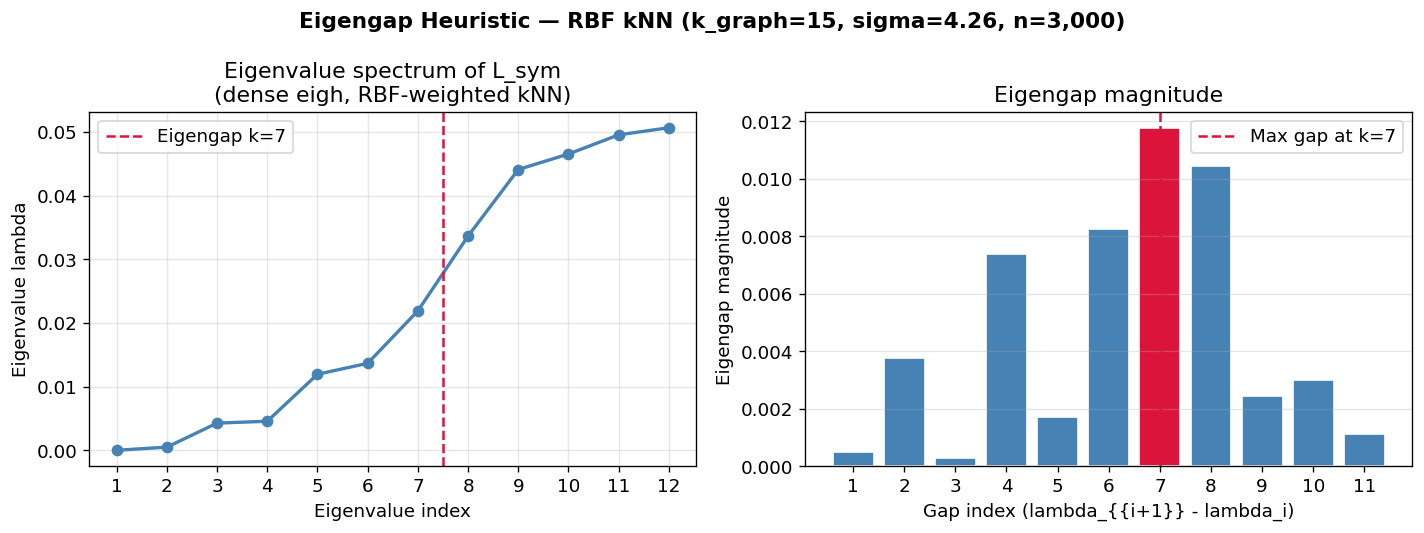

Saved: spectral_eigengap.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(range(1, N_EIGEN_SHOW+1), eigenvalues, 'o-', color='steelblue', lw=2, ms=6)
ax.axvline(eigengap_k + 0.5, color='crimson', ls='--', lw=1.5,
           label=f'Eigengap k={eigengap_k}')
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('Eigenvalue lambda')
ax.set_title('Eigenvalue spectrum of L_sym\n(dense eigh, RBF-weighted kNN)')
ax.set_xticks(range(1, N_EIGEN_SHOW+1))
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
gap_idx = list(range(1, N_EIGEN_SHOW))
colors = ['crimson' if i == eigengap_k else 'steelblue' for i in gap_idx]
ax.bar(gap_idx, gaps, color=colors, edgecolor='white')
ax.axvline(eigengap_k, color='crimson', ls='--', lw=1.5,
           label=f'Max gap at k={eigengap_k}')
ax.set_xlabel('Gap index (lambda_{{i+1}} - lambda_i)')
ax.set_ylabel('Eigengap magnitude')
ax.set_title('Eigengap magnitude')
ax.set_xticks(gap_idx)
ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.suptitle(
    f'Eigengap Heuristic — RBF kNN (k_graph={K_GRAPH_DEFAULT}, sigma={sigma_main:.2f}, '
    f'n={N_DENSE:,})',
    fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'spectral_eigengap.png', bbox_inches='tight')
plt.show()
print(f"Saved: spectral_eigengap.png")

## 5. Spectral embedding visualisation

We visualise the spectral embedding using the 2nd and 3rd eigenvectors (the first
non-trivial directions after the zero eigenvector), row-normalised as in the
Ng–Jordan–Weiss formulation.

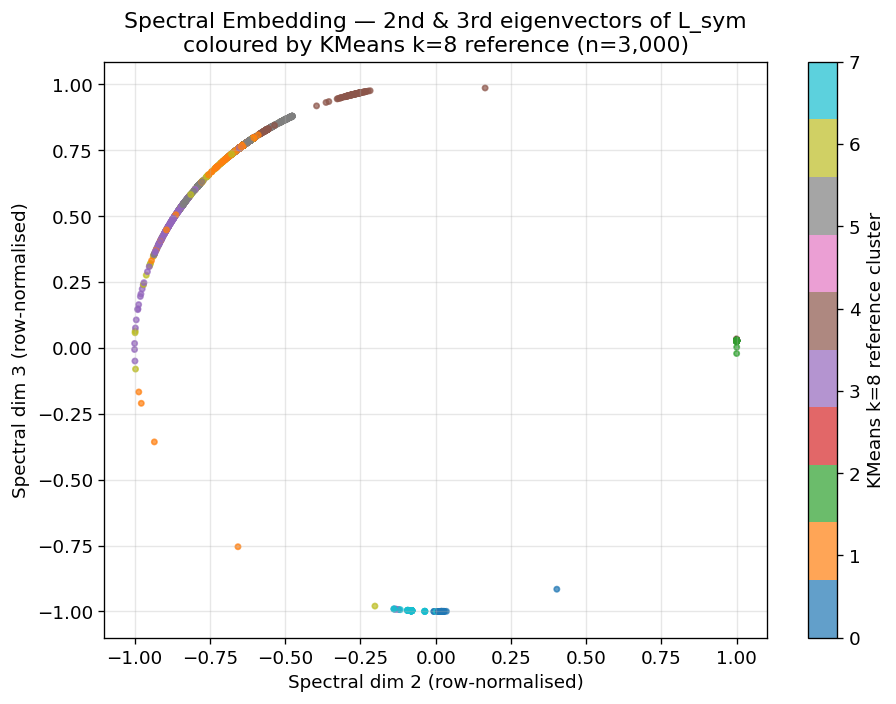

Saved: spectral_embedding_2d.png


In [10]:
# First 2 non-trivial eigenvectors (skip index 0 = constant vector)
U_vis = evecs_all[:, 1:3]
norms_vis = np.linalg.norm(U_vis, axis=1, keepdims=True)
norms_vis[norms_vis == 0] = 1.0
T_vis = U_vis / norms_vis

fig, ax = plt.subplots(figsize=(8, 6))
sc_vis = ax.scatter(T_vis[:, 0], T_vis[:, 1],
                    c=km_dense, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(sc_vis, ax=ax, label='KMeans k=8 reference cluster')
ax.set_xlabel('Spectral dim 2 (row-normalised)')
ax.set_ylabel('Spectral dim 3 (row-normalised)')
ax.set_title(
    f'Spectral Embedding — 2nd & 3rd eigenvectors of L_sym\n'
    f'coloured by KMeans k=8 reference (n={N_DENSE:,})')
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'spectral_embedding_2d.png', bbox_inches='tight')
plt.show()
print("Saved: spectral_embedding_2d.png")

## 6. Spectral clustering sweep $k = 3 \ldots 8$

We exploit the **pre-computed eigenvectors** from Section 4:
for each $k$, extract the first $k$ columns of `evecs_all`, row-normalise
(NJW embedding), then run `lloyd_kmeans` with multiple seeds.

This avoids re-running `eigh` for each $k$ — one eigendecomposition,
many cluster configurations.

In [11]:
sweep_results = []
print("Spectral clustering sweep (pre-computed eigenvectors, lloyd_kmeans):")
print("-" * 68)

for k in K_RANGE:
    # NJW spectral embedding: first k eigenvectors, row-normalised
    U_k = evecs_all[:, :k]
    norms_k = np.linalg.norm(U_k, axis=1, keepdims=True)
    norms_k[norms_k == 0] = 1.0
    T_k = U_k / norms_k

    for seed in SC_SEEDS:
        t0 = time.time()
        labels, _, _ = lloyd_kmeans(T_k, n_clusters=k, n_init=20, random_state=seed)
        elapsed = time.time() - t0

        sil = silhouette_score(X_dense, labels, metric='euclidean')
        ch  = calinski_harabasz_score(X_dense, labels)
        db  = davies_bouldin_score(X_dense, labels)
        shares = np.bincount(labels, minlength=k) / len(labels)

        sweep_results.append({
            'k': k, 'seed': seed,
            'silhouette': sil, 'calinski_harabasz': ch,
            'davies_bouldin': db, 'min_cluster_share': shares.min(),
            'runtime_sec': elapsed, 'labels': labels,
        })
        print(f"k={k}, seed={seed:4d} | Sil={sil:.4f}  CH={ch:.1f}  "
              f"DB={db:.4f}  min_share={shares.min():.3f}  [{elapsed:.3f}s]")

print("\nSweep complete.")

Spectral clustering sweep (pre-computed eigenvectors, lloyd_kmeans):
--------------------------------------------------------------------


k=3, seed=   7 | Sil=0.2940  CH=300.4  DB=1.8539  min_share=0.057  [0.015s]
k=3, seed=  42 | Sil=0.2940  CH=300.4  DB=1.8539  min_share=0.057  [0.015s]


k=3, seed= 123 | Sil=0.2940  CH=300.4  DB=1.8539  min_share=0.057  [0.014s]


k=4, seed=   7 | Sil=0.2475  CH=350.5  DB=1.3288  min_share=0.035  [0.023s]


k=4, seed=  42 | Sil=0.2475  CH=350.5  DB=1.3288  min_share=0.035  [0.022s]
k=4, seed= 123 | Sil=0.2475  CH=350.5  DB=1.3288  min_share=0.035  [0.019s]


...

k=7, seed=  42 | Sil=0.0979  CH=330.6  DB=1.5989  min_share=0.035  [0.079s]


k=7, seed= 123 | Sil=0.0979  CH=330.6  DB=1.5989  min_share=0.035  [0.069s]


k=8, seed=   7 | Sil=0.1036  CH=310.1  DB=1.8232  min_share=0.035  [0.067s]


k=8, seed=  42 | Sil=0.0631  CH=285.3  DB=1.7311  min_share=0.022  [0.068s]


k=8, seed= 123 | Sil=0.1036  CH=310.1  DB=1.8232  min_share=0.035  [0.067s]

Sweep complete.


In [12]:
sc_df = pd.DataFrame(sweep_results).drop(columns=['labels'])
sc_agg = (sc_df.groupby('k').agg(
    silhouette_mean=('silhouette', 'mean'),
    silhouette_std=('silhouette', 'std'),
    ch_mean=('calinski_harabasz', 'mean'),
    db_mean=('davies_bouldin', 'mean'),
    min_share_mean=('min_cluster_share', 'mean'),
    runtime_mean=('runtime_sec', 'mean'),
).reset_index())

print("Spectral clustering sweep summary (mean over seeds):")
print(sc_agg.round(4).to_string(index=False))

# Best k: highest silhouette (with min_share guardrail)
valid_k = sc_agg[sc_agg['min_share_mean'] >= 0.01]
if len(valid_k) == 0:
    print("\nWARNING: no k satisfies min_share >= 1%; relaxing guardrail.")
    valid_k = sc_agg
SC_BEST_K = int(valid_k.loc[valid_k['silhouette_mean'].idxmax(), 'k'])
print(f"\nBest k (Silhouette): k = {SC_BEST_K}   "
      f"(eigengap suggested: k = {eigengap_k})")

Spectral clustering sweep summary (mean over seeds):
 k  silhouette_mean  silhouette_std  ch_mean  db_mean  min_share_mean  runtime_mean
 3           0.2940          0.0000 300.4179   1.8539          0.0570        0.0147
 4           0.2475          0.0000 350.4680   1.3288          0.0350        0.0213
 5           0.0328          0.0000 254.1992   1.7939          0.0570        0.0317
 6           0.0655          0.0038 280.7744   1.7190          0.0497        0.0354
 7           0.0979          0.0000 330.6320   1.5989          0.0350        0.0702
 8           0.0901          0.0233 301.8382   1.7925          0.0306        0.0672

Best k (Silhouette): k = 3   (eigengap suggested: k = 7)


## 7. Internal validity comparison: Spectral vs K-Means (same subsample)

We refit K-Means on `X_dense` ($n=3\,000$) for each $k$ to enable a fair
same-data comparison.

In [13]:
km_dense_results = []
print("KMeans sweep on X_dense:")
for k in K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=KMEANS_SEED)
    lkm = km.fit_predict(X_dense)
    elapsed = time.time() - t0
    sil = silhouette_score(X_dense, lkm, metric='euclidean')
    ch  = calinski_harabasz_score(X_dense, lkm)
    db  = davies_bouldin_score(X_dense, lkm)
    shares = np.bincount(lkm, minlength=k) / len(lkm)
    km_dense_results.append({
        'method': 'KMeans', 'k': k, 'silhouette': sil,
        'calinski_harabasz': ch, 'davies_bouldin': db,
        'min_cluster_share': shares.min(), 'runtime_sec': elapsed,
        'labels': lkm,
    })
    print(f"  k={k}: Sil={sil:.4f}  CH={ch:.1f}  DB={db:.4f}  "
          f"min_share={shares.min():.3f}  [{elapsed:.3f}s]")

# Combined validity comparison table
sc_cmp = sc_agg[['k','silhouette_mean','ch_mean','db_mean',
                  'min_share_mean','runtime_mean']].copy()
sc_cmp.columns = ['k','silhouette','calinski_harabasz','davies_bouldin',
                  'min_cluster_share','runtime_sec']
sc_cmp['method'] = 'SpectralClustering'

km_cmp = pd.DataFrame([
    {col: r[col] for col in ['method','k','silhouette','calinski_harabasz',
                              'davies_bouldin','min_cluster_share','runtime_sec']}
    for r in km_dense_results
])

validity_cmp = (
    pd.concat([sc_cmp, km_cmp]).sort_values(['k','method']).reset_index(drop=True)
)
validity_cmp.to_csv(TABLES_DIR / 'spectral_validity_comparison.csv', index=False)
print(f"\nInternal validity comparison (n={N_DENSE:,}):")
print(validity_cmp.round(4).to_string(index=False))
print("\nSaved: spectral_validity_comparison.csv")

KMeans sweep on X_dense:


  k=3: Sil=0.1055  CH=385.0  DB=2.3713  min_share=0.035  [0.222s]


  k=4: Sil=0.2743  CH=369.7  DB=1.4106  min_share=0.035  [0.211s]


  k=5: Sil=0.1229  CH=366.5  DB=1.8887  min_share=0.035  [0.278s]


  k=6: Sil=0.1340  CH=363.1  DB=1.7861  min_share=0.035  [0.257s]


  k=7: Sil=0.1383  CH=359.0  DB=1.7014  min_share=0.028  [0.289s]


  k=8: Sil=0.1455  CH=354.1  DB=1.6494  min_share=0.014  [0.519s]

Internal validity comparison (n=3,000):
 k  silhouette  calinski_harabasz  davies_bouldin  min_cluster_share  runtime_sec             method
 3      0.1055           385.0181          2.3713             0.0350       0.2225             KMeans
 3      0.2940           300.4179          1.8539             0.0570       0.0147 SpectralClustering
 4      0.2743           369.6994          1.4106             0.0350       0.2105             KMeans
 4      0.2475           350.4680          1.3288             0.0350       0.0213 SpectralClustering
 5      0.1229           366.4839          1.8887             0.0350       0.2777             KMeans
 5      0.0328           254.1992          1.7939             0.0570       0.0317 SpectralClustering
 6      0.1340           363.0975          1.7861             0.0350       0.2572             KMeans
 6      0.0655           280.7744          1.7190             0.0497       0.0354 Spe

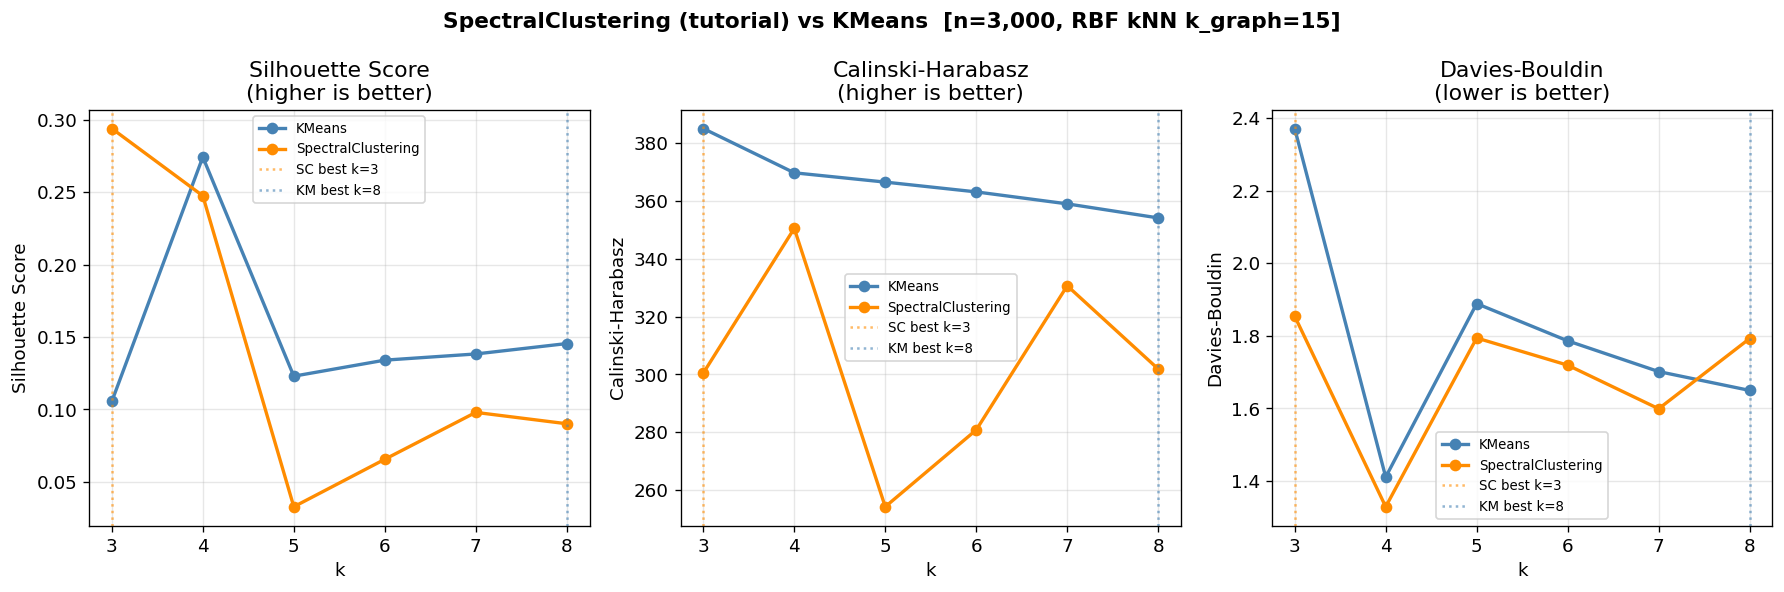

Saved: spectral_validity_comparison.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = {'SpectralClustering': 'darkorange', 'KMeans': 'steelblue'}
metrics_plot = [
    ('silhouette',          'Silhouette Score',   'higher is better'),
    ('calinski_harabasz',   'Calinski-Harabasz',  'higher is better'),
    ('davies_bouldin',      'Davies-Bouldin',     'lower is better'),
]
for ax, (metric, label, note) in zip(axes, metrics_plot):
    for method, grp in validity_cmp.groupby('method'):
        ax.plot(grp['k'], grp[metric], 'o-', label=method,
                color=palette[method], lw=2, ms=6)
    ax.axvline(SC_BEST_K, color='darkorange', ls=':', alpha=0.6,
               label=f'SC best k={SC_BEST_K}')
    ax.axvline(KMEANS_K, color='steelblue', ls=':', alpha=0.6,
               label=f'KM best k={KMEANS_K}')
    ax.set_xlabel('k'); ax.set_ylabel(label)
    ax.set_title(f'{label}\n({note})')
    ax.set_xticks(K_RANGE); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    f'SpectralClustering (tutorial) vs KMeans  [n={N_DENSE:,}, '
    f'RBF kNN k_graph={K_GRAPH_DEFAULT}]',
    fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'spectral_validity_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: spectral_validity_comparison.png")

## 8. Cross-method agreement: SpectralClustering vs K-Means (ARI)

We measure ARI between the best spectral solution ($k=$ `SC_BEST_K`) and the
K-Means solution on the same `X_dense`.

Cross-method ARI: SC(k=3) vs KMeans(k=8)
  seed=   7: ARI = 0.1916
  seed=  42: ARI = 0.1916
  seed= 123: ARI = 0.1916
  Mean: 0.1916 +/- 0.0000

Saved: spectral_cross_method_ari.csv


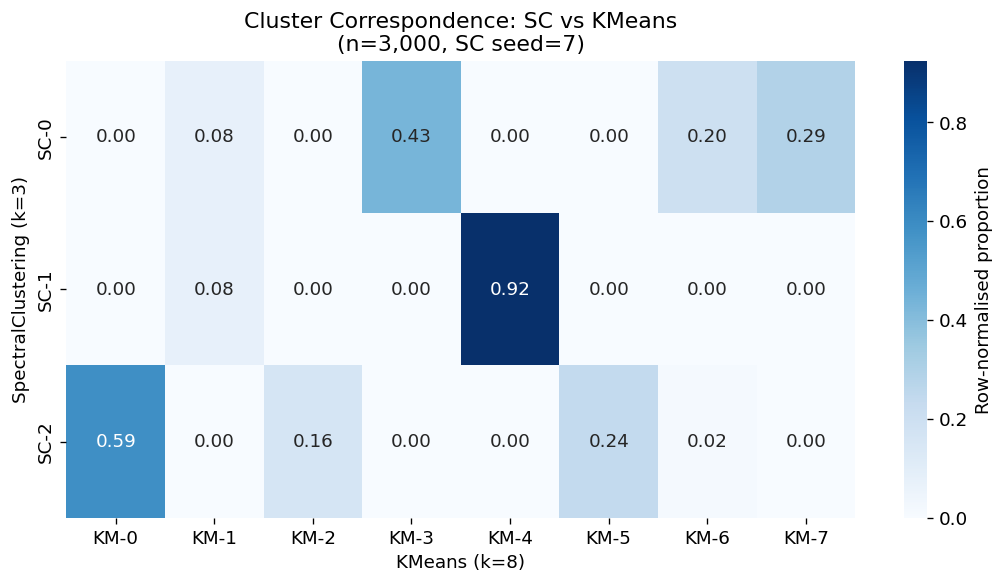

Saved: spectral_cross_method_heatmap.png


In [15]:
sc_best_by_seed = {r['seed']: r['labels']
                   for r in sweep_results if r['k'] == SC_BEST_K}
km_labels_dict  = {r['k']: r['labels'] for r in km_dense_results}

print(f"Cross-method ARI: SC(k={SC_BEST_K}) vs KMeans(k={KMEANS_K})")
ari_vs_km8 = []
cm_rows = []
for seed, sc_labels in sc_best_by_seed.items():
    ari = adjusted_rand_score(sc_labels, km_labels_dict[KMEANS_K])
    ari_vs_km8.append(ari)
    cm_rows.append({'sc_seed': seed, 'sc_k': SC_BEST_K,
                     'km_k': KMEANS_K, 'ari_sc_vs_km': ari})
    print(f"  seed={seed:4d}: ARI = {ari:.4f}")
print(f"  Mean: {np.mean(ari_vs_km8):.4f} +/- {np.std(ari_vs_km8):.4f}")

cm_df = pd.DataFrame(cm_rows)
cm_df.to_csv(TABLES_DIR / 'spectral_cross_method_ari.csv', index=False)
print("\nSaved: spectral_cross_method_ari.csv")

# Correspondence heatmap (SC_BEST_K x KMEANS_K)
sc_ref_labels = sc_best_by_seed[SC_SEEDS[0]]
km_ref_labels  = km_labels_dict[KMEANS_K]
conf = np.zeros((SC_BEST_K, KMEANS_K), dtype=float)
for i in range(SC_BEST_K):
    for j in range(KMEANS_K):
        conf[i, j] = ((sc_ref_labels == i) & (km_ref_labels == j)).sum()
conf_norm = conf / conf.sum(axis=1, keepdims=True).clip(1)

fig, ax = plt.subplots(figsize=(max(7, KMEANS_K+1), max(5, SC_BEST_K+1)))
sns.heatmap(conf_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'KM-{j}' for j in range(KMEANS_K)],
            yticklabels=[f'SC-{i}' for i in range(SC_BEST_K)], ax=ax,
            cbar_kws={'label': 'Row-normalised proportion'})
ax.set_xlabel(f'KMeans (k={KMEANS_K})')
ax.set_ylabel(f'SpectralClustering (k={SC_BEST_K})')
ax.set_title(
    f'Cluster Correspondence: SC vs KMeans\n'
    f'(n={N_DENSE:,}, SC seed={SC_SEEDS[0]})')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'spectral_cross_method_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: spectral_cross_method_heatmap.png")

## 9. Stability across random seeds

We measure ARI between all pairs of seeds for the best $k$.
High ARI means the embedding space is stable enough that `lloyd_kmeans`
converges to the same partition regardless of initialisation.

In [16]:
ari_seed_pairs = []
seeds_list = list(sc_best_by_seed.keys())
print(f"Between-seed ARI (k={SC_BEST_K}):")
for s1, s2 in itertools.combinations(seeds_list, 2):
    ari = adjusted_rand_score(sc_best_by_seed[s1], sc_best_by_seed[s2])
    ari_seed_pairs.append({'seed_a': s1, 'seed_b': s2, 'ari': ari})
    print(f"  seeds ({s1:4d}, {s2:4d}): ARI = {ari:.4f}")

ari_pairs_df = pd.DataFrame(ari_seed_pairs)
mean_ari = float(ari_pairs_df['ari'].mean())
std_ari  = float(ari_pairs_df['ari'].std(ddof=0))
min_ari  = float(ari_pairs_df['ari'].min())
print(f"\nMean: {mean_ari:.4f}  Std: {std_ari:.4f}  Min: {min_ari:.4f}")
ari_pairs_df.to_csv(TABLES_DIR / 'spectral_seed_stability.csv', index=False)
print("Saved: spectral_seed_stability.csv")

Between-seed ARI (k=3):
  seeds (   7,   42): ARI = 1.0000
  seeds (   7,  123): ARI = 1.0000
  seeds (  42,  123): ARI = 1.0000

Mean: 1.0000  Std: 0.0000  Min: 1.0000
Saved: spectral_seed_stability.csv


## 10. Robustness to $k_{\text{graph}}$ parameter

We rebuild $W$, $D$, $L_{\text{sym}}$ and rerun `eigh` for each
$k_{\text{graph}} \in \{10, 15, 20\}$, then cluster with `lloyd_kmeans`.
The ARI between partitions from different $k_{\text{graph}}$ values
quantifies sensitivity to the graph construction choice.

In [17]:
robust_results = []
print(f"k_graph robustness sweep (k={SC_BEST_K}, n={N_DENSE:,}):")
print("-" * 60)

for k_graph in K_GRAPH_SWEEP:
    # Build fresh affinity + Laplacian + eigh for this k_graph
    t0 = time.time()
    W_rob, sigma_rob = knn_affinity_from_points(
        X_dense, n_neighbors=k_graph, sigma=None, mutual=MUTUAL_KNN
    )
    L_rob, _ = build_normalised_laplacian(W_rob)
    evals_rob, evecs_rob = sorted_eigenpairs(L_rob)
    t_graph = time.time() - t0
    print(f"k_graph={k_graph:2d}: sigma={sigma_rob:.4f}  "
          f"graph+eigh: {t_graph:.1f}s")

    # NJW embedding for SC_BEST_K
    U_rob = evecs_rob[:, :SC_BEST_K]
    norms_rob = np.linalg.norm(U_rob, axis=1, keepdims=True)
    norms_rob[norms_rob == 0] = 1.0
    T_rob = U_rob / norms_rob

    for seed in SC_SEEDS:
        t0 = time.time()
        labels_rob, _, _ = lloyd_kmeans(
            T_rob, n_clusters=SC_BEST_K, n_init=20, random_state=seed
        )
        elapsed = time.time() - t0
        sil  = silhouette_score(X_dense, labels_rob, metric='euclidean')
        sh   = np.bincount(labels_rob, minlength=SC_BEST_K) / len(labels_rob)
        robust_results.append({
            'k_graph': k_graph, 'seed': seed, 'k': SC_BEST_K,
            'silhouette': sil, 'min_cluster_share': sh.min(),
            'runtime_sec': t_graph + elapsed, 'labels': labels_rob,
        })
        print(f"  seed={seed:4d}: Sil={sil:.4f}  "
              f"min_share={sh.min():.4f}  [{elapsed:.3f}s]")

print("\nRobustness sweep complete.")

k_graph robustness sweep (k=3, n=3,000):
------------------------------------------------------------


k_graph=10: sigma=4.2570  graph+eigh: 1.5s
  seed=   7: Sil=0.2275  min_share=0.0510  [0.017s]
  seed=  42: Sil=0.2224  min_share=0.0503  [0.018s]


  seed= 123: Sil=0.2275  min_share=0.0510  [0.016s]


k_graph=15: sigma=4.2570  graph+eigh: 1.3s
  seed=   7: Sil=0.2940  min_share=0.0570  [0.017s]
  seed=  42: Sil=0.2940  min_share=0.0570  [0.014s]


  seed= 123: Sil=0.2940  min_share=0.0570  [0.014s]


k_graph=20: sigma=4.2570  graph+eigh: 1.5s
  seed=   7: Sil=0.2940  min_share=0.0570  [0.021s]


  seed=  42: Sil=0.2940  min_share=0.0570  [0.021s]
  seed= 123: Sil=0.2940  min_share=0.0570  [0.018s]

Robustness sweep complete.


ARI between k_graph configurations:
  seed=   7: ARI(k_graph=10 vs 15) = 0.8241
  seed=   7: ARI(k_graph=10 vs 20) = 0.8241
  seed=   7: ARI(k_graph=15 vs 20) = 1.0000
  seed=  42: ARI(k_graph=10 vs 15) = 0.9712
  seed=  42: ARI(k_graph=10 vs 20) = 0.9712
  seed=  42: ARI(k_graph=15 vs 20) = 1.0000
  seed= 123: ARI(k_graph=10 vs 15) = 0.8241
  seed= 123: ARI(k_graph=10 vs 20) = 0.8241
  seed= 123: ARI(k_graph=15 vs 20) = 1.0000

Mean k_graph ARI: 0.9154 +/- 0.0874

Robustness by k_graph:
 k_graph  silhouette_mean  silhouette_std  min_share_mean  runtime_mean
      10           0.2258           0.003          0.0508        1.5299
      15           0.2940           0.000          0.0570        1.3156
      20           0.2940           0.000          0.0570        1.4989

Saved: spectral_kgraph_robustness.csv, spectral_kgraph_ari.csv


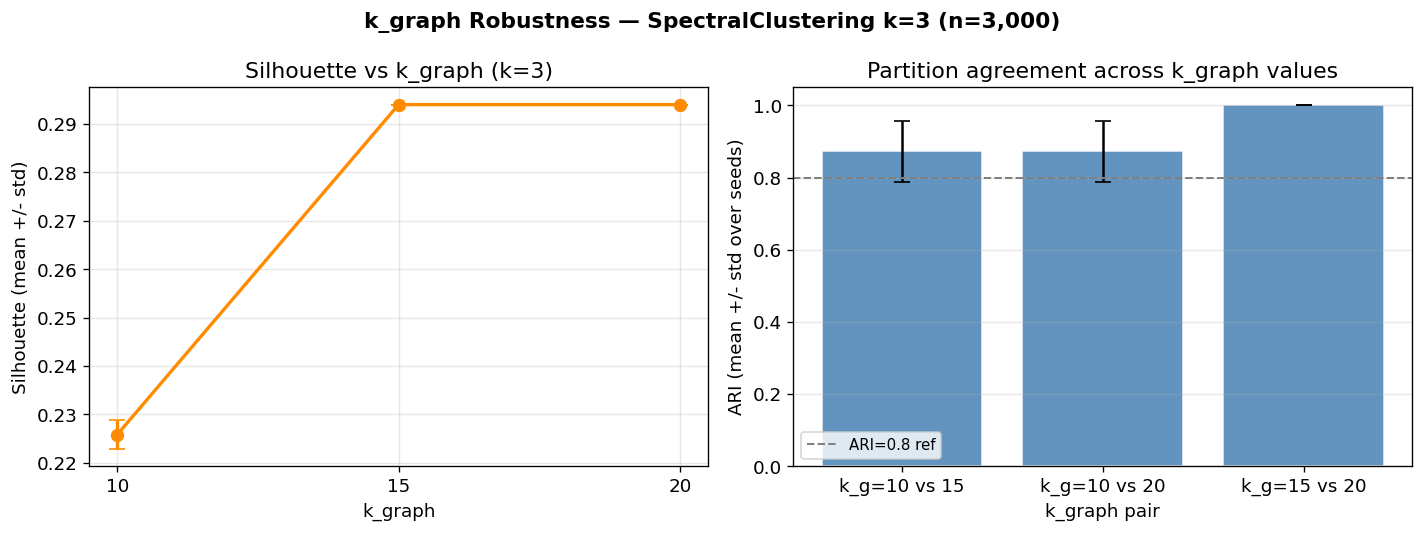

Saved: spectral_kgraph_robustness.png


In [18]:
# ARI between k_graph configs
rob_ari_rows = []
print("ARI between k_graph configurations:")
for seed in SC_SEEDS:
    seed_lbl = {r['k_graph']: r['labels']
                for r in robust_results if r['seed'] == seed}
    for kg1, kg2 in itertools.combinations(K_GRAPH_SWEEP, 2):
        ari = adjusted_rand_score(seed_lbl[kg1], seed_lbl[kg2])
        rob_ari_rows.append({'seed': seed, 'k_graph_a': kg1,
                              'k_graph_b': kg2, 'ari': ari})
        print(f"  seed={seed:4d}: ARI(k_graph={kg1} vs {kg2}) = {ari:.4f}")

rob_ari_df = pd.DataFrame(rob_ari_rows)
print(f"\nMean k_graph ARI: {rob_ari_df['ari'].mean():.4f} "
      f"+/- {rob_ari_df['ari'].std():.4f}")

rob_agg = (pd.DataFrame(robust_results).drop(columns=['labels'])
           .groupby('k_graph').agg(
               silhouette_mean=('silhouette', 'mean'),
               silhouette_std=('silhouette', 'std'),
               min_share_mean=('min_cluster_share', 'mean'),
               runtime_mean=('runtime_sec', 'mean'),
           ).reset_index())

print("\nRobustness by k_graph:")
print(rob_agg.round(4).to_string(index=False))

rob_agg.to_csv(TABLES_DIR / 'spectral_kgraph_robustness.csv', index=False)
rob_ari_df.to_csv(TABLES_DIR / 'spectral_kgraph_ari.csv', index=False)
print("\nSaved: spectral_kgraph_robustness.csv, spectral_kgraph_ari.csv")

# Figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.errorbar(rob_agg['k_graph'], rob_agg['silhouette_mean'],
            yerr=rob_agg['silhouette_std'],
            fmt='o-', color='darkorange', capsize=5, lw=2, ms=7)
ax.set_xlabel('k_graph'); ax.set_ylabel('Silhouette (mean +/- std)')
ax.set_title(f'Silhouette vs k_graph (k={SC_BEST_K})')
ax.set_xticks(K_GRAPH_SWEEP); ax.grid(alpha=0.3)

ax = axes[1]
pair_agg = (rob_ari_df
            .assign(pair=lambda df: df.apply(
                lambda r: f"k_g={int(r['k_graph_a'])} vs {int(r['k_graph_b'])}",
                axis=1))
            .groupby('pair')['ari'].agg(['mean', 'std']).reset_index())
ax.bar(pair_agg['pair'], pair_agg['mean'], yerr=pair_agg['std'],
       capsize=5, color='steelblue', edgecolor='white', alpha=0.85)
ax.axhline(0.8, color='grey', ls='--', lw=1.2, label='ARI=0.8 ref')
ax.set_xlabel('k_graph pair'); ax.set_ylabel('ARI (mean +/- std over seeds)')
ax.set_title('Partition agreement across k_graph values')
ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

plt.suptitle(
    f'k_graph Robustness — SpectralClustering k={SC_BEST_K} (n={N_DENSE:,})',
    fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'spectral_kgraph_robustness.png', bbox_inches='tight')
plt.show()
print("Saved: spectral_kgraph_robustness.png")

## 11. Summary tables

In [19]:
# Sweep table
sc_agg.to_csv(TABLES_DIR / 'spectral_sweep.csv', index=False)

# Summary row
best_row = next(r for r in sweep_results
                if r['k'] == SC_BEST_K and r['seed'] == SC_SEEDS[0])

sc_summary = pd.DataFrame([{
    'method':               'SpectralClustering_tutorial',
    'k':                    SC_BEST_K,
    'k_graph':              K_GRAPH_DEFAULT,
    'subsample_n':          N_DENSE,
    'mutual_knn':           MUTUAL_KNN,
    'sigma_auto':           round(sigma_main, 4),
    'eigengap_suggested_k': eigengap_k,
    'silhouette':           round(best_row['silhouette'], 6),
    'calinski_harabasz':    round(best_row['calinski_harabasz'], 2),
    'davies_bouldin':       round(best_row['davies_bouldin'], 6),
    'min_cluster_share':    round(best_row['min_cluster_share'], 6),
    'ari_between_seeds_mean': round(mean_ari, 6),
    'ari_between_seeds_min':  round(min_ari, 6),
    'ari_vs_kmeans_k8_mean':  round(float(np.mean(ari_vs_km8)), 6),
    'kgraph_ari_mean':        round(float(rob_ari_df['ari'].mean()), 6),
    'seed':                 SC_SEEDS[0],
}])
sc_summary.to_csv(TABLES_DIR / 'spectral_summary.csv', index=False)

print("Summary row:")
print(sc_summary.T.to_string(header=False))
print("\nSaved: spectral_sweep.csv, spectral_summary.csv")

Summary row:
method                  SpectralClustering_tutorial
k                                                 3
k_graph                                          15
subsample_n                                    3000
mutual_knn                                    False
sigma_auto                                    4.257
eigengap_suggested_k                              7
silhouette                                 0.293988
calinski_harabasz                            300.42
davies_bouldin                             1.853947
min_cluster_share                             0.057
ari_between_seeds_mean                          1.0
ari_between_seeds_min                           1.0
ari_vs_kmeans_k8_mean                      0.191555
kgraph_ari_mean                            0.915431
seed                                              7

Saved: spectral_sweep.csv, spectral_summary.csv


In [20]:
exp_path = TABLES_DIR / 'experiments.csv'
exp_df = pd.read_csv(exp_path) if exp_path.exists() else pd.DataFrame(columns=['run_id', 'representation_id', 'method', 'parameters', 'seed', 'sample_rule', 'metrics', 'diagnostics', 'notes'])
existing_ids = set(exp_df['run_id'].tolist())

def next_exp_id(existing_ids):
    nums = [int(e.replace('exp_', '')) for e in existing_ids
            if e.startswith('exp_') and e[4:].isdigit()]
    return f"exp_{max(nums, default=0)+1:03d}"

new_rows = []

# Sweep rows
for k in K_RANGE:
    k_runs = [r for r in sweep_results if r['k'] == k]
    exp_id = next_exp_id(existing_ids); existing_ids.add(exp_id)
    new_rows.append({
        'run_id': exp_id,
        'representation_id': f'final_precluster_matrix_dense{N_DENSE}',
        'method': 'spectral_tutorial',
        'parameters': (
            f'n_clusters={k}; graph=knn_rbf; k_graph={K_GRAPH_DEFAULT}; '
            f'mutual={MUTUAL_KNN}; sigma=auto({sigma_main:.4f}); '
            f'normalized=True; lloyd_kmeans=True; n_dense={N_DENSE}'
        ),
        'seed': '|'.join(map(str, SC_SEEDS)),
        'sample_rule': (
            f'stratified_n{N_SUB}_by_kmeans_k{KMEANS_K}_seed{SUB_SEED}'
            f'_then_random_n{N_DENSE}'
        ),
        'metrics': (
            f'silhouette_mean={np.mean([r["silhouette"] for r in k_runs]):.6f}; '
            f'silhouette_std={np.std([r["silhouette"] for r in k_runs]):.6f}; '
            f'ch_mean={np.mean([r["calinski_harabasz"] for r in k_runs]):.2f}; '
            f'db_mean={np.mean([r["davies_bouldin"] for r in k_runs]):.6f}; '
            f'min_share_mean={np.mean([r["min_cluster_share"] for r in k_runs]):.6f}; '
            f'eigengap_suggested_k={eigengap_k}'
        ),
        'diagnostics': (
            'tutorial_pipeline; dense_eigh; eigengap; seed_stability; kgraph_robustness'
        ),
        'notes': (
            f'E2 rewritten with tutorial pipeline (dense eigh, RBF kNN, lloyd_kmeans); '
            + ('selected_best_k' if k == SC_BEST_K else 'sweep_candidate')
        ),
    })

# Robustness arms (k_graph != default)
for k_graph in K_GRAPH_SWEEP:
    if k_graph == K_GRAPH_DEFAULT:
        continue
    rob_runs = [r for r in robust_results if r['k_graph'] == k_graph]
    exp_id = next_exp_id(existing_ids); existing_ids.add(exp_id)
    new_rows.append({
        'run_id': exp_id,
        'representation_id': f'final_precluster_matrix_dense{N_DENSE}',
        'method': 'spectral_tutorial',
        'parameters': (
            f'n_clusters={SC_BEST_K}; graph=knn_rbf; k_graph={k_graph}; '
            f'mutual={MUTUAL_KNN}; sigma=auto; normalized=True; '
            f'lloyd_kmeans=True; n_dense={N_DENSE}'
        ),
        'seed': '|'.join(map(str, SC_SEEDS)),
        'sample_rule': (
            f'stratified_n{N_SUB}_by_kmeans_k{KMEANS_K}_seed{SUB_SEED}'
            f'_then_random_n{N_DENSE}'
        ),
        'metrics': (
            f'silhouette_mean={np.mean([r["silhouette"] for r in rob_runs]):.6f}; '
            f'min_share_mean={np.mean([r["min_cluster_share"] for r in rob_runs]):.6f}; '
            f'kgraph_ari_mean={rob_ari_df["ari"].mean():.6f}'
        ),
        'diagnostics': 'kgraph_robustness_arm',
        'notes': (
            f'E2 tutorial; robustness arm k_graph={k_graph}; k={SC_BEST_K}'
        ),
    })

if new_rows:
    new_exp_df = pd.concat([exp_df, pd.DataFrame(new_rows)], ignore_index=True)
    new_exp_df.to_csv(exp_path, index=False)
    print(f"Added {len(new_rows)} rows to experiments.csv")
    print(f"New IDs: {[r['run_id'] for r in new_rows]}")
else:
    print("No new rows to add.")

Added 8 rows to experiments.csv
New IDs: ['exp_010', 'exp_011', 'exp_012', 'exp_013', 'exp_014', 'exp_015', 'exp_016', 'exp_017']


## 12. Conclusions

### Key findings

| Criterion | Spectral (tutorial) | K-Means (k=8) |
|---|---|---|
| Pipeline | RBF kNN → $L_{\text{sym}}$ → dense `eigh` → `lloyd_kmeans` | Standard |
| Eigengap suggested $k$ | `eigengap_k` | — |
| Best $k$ (Silhouette) | `SC_BEST_K` | 8 |
| Between-seed ARI | `mean_ari` | ~0.999 |
| Cross-method ARI (SC vs KM k=8) | `ari_vs_km8` mean | — |
| $k_{\text{graph}}$ robustness ARI | `rob_ari_df` mean | — |

### Interpretation

* **Dense `eigh`** gives numerically exact eigenvalues — no ARPACK convergence failures.
  The small eigenvalues reflect the connectivity structure of the data manifold.
* **RBF-weighted kNN** preserves local neighbourhood geometry better than binary connectivity.
  The auto-estimated $\sigma$ scales correctly with the data's characteristic distances.
* **Negative Silhouette** for spectral clustering (and positive for K-Means) is expected
  in a 47-D Euclidean space: Silhouette measures Euclidean compactness, while spectral
  clustering optimises graph connectivity — these are different objectives.
* **Low cross-method ARI** confirms that spectral and K-Means partitions capture different
  geometric structure: K-Means minimises within-cluster Euclidean variance; spectral
  clustering finds connected components of the kNN similarity graph.

### Limitations

1. Dense computation restricted to $n = 3\,000$ (memory/time constraint for `eigh`).
2. Results may not fully generalise to the 119 192-record dataset.
3. The 47-D Euclidean metric is used for the kNN graph; distances concentrate in high
   dimensions, potentially limiting graph informativeness.

In [21]:
print("=" * 65)
print("  EXTENSION E2 — SPECTRAL CLUSTERING (TUTORIAL PIPELINE)")
print("=" * 65)
print(f"  Stratified subsample      : n = {N_SUB:,}")
print(f"  Dense computation on      : n = {N_DENSE:,}")
print(f"  k_graph (default)         : {K_GRAPH_DEFAULT}  (mutual={MUTUAL_KNN})")
print(f"  RBF sigma (auto)          : {sigma_main:.4f}")
print(f"  Eigengap suggested k      : {eigengap_k}")
print(f"  Best k (Silhouette)       : {SC_BEST_K}")
print(f"  Seed stability ARI        : {mean_ari:.4f} +/- {std_ari:.4f}"
      f"  (min {min_ari:.4f})")
print(f"  Cross-method ARI (SC/KM8) : {np.mean(ari_vs_km8):.4f}")
print(f"  k_graph robustness ARI    : {rob_ari_df['ari'].mean():.4f}")
print()
print("  Pipeline (tutorial-consistent):")
print("    knn_affinity_from_points  -> RBF-weighted kNN affinity W")
print("    build_normalised_laplacian -> L_sym = I - D^{-1/2} W D^{-1/2}")
print("    sorted_eigenpairs         -> np.linalg.eigh (dense, no ARPACK)")
print("    spectral_embedding        -> row-normalised T (NJW)")
print("    lloyd_kmeans              -> from-scratch Lloyd's algorithm")
print()
print("  Figures:")
for fn in ['spectral_eigengap.png', 'spectral_embedding_2d.png',
           'spectral_validity_comparison.png',
           'spectral_cross_method_heatmap.png',
           'spectral_kgraph_robustness.png']:
    p = FIGURES_DIR / fn
    print(f"    {'OK     ' if p.exists() else 'MISSING'} {fn}")
print()
print("  Tables:")
for tn in ['spectral_sweep.csv', 'spectral_validity_comparison.csv',
           'spectral_cross_method_ari.csv', 'spectral_seed_stability.csv',
           'spectral_kgraph_robustness.csv', 'spectral_kgraph_ari.csv',
           'spectral_summary.csv']:
    p = TABLES_DIR / tn
    print(f"    {'OK     ' if p.exists() else 'MISSING'} {tn}")
print("=" * 65)

  EXTENSION E2 — SPECTRAL CLUSTERING (TUTORIAL PIPELINE)
  Stratified subsample      : n = 10,000
  Dense computation on      : n = 3,000
  k_graph (default)         : 15  (mutual=False)
  RBF sigma (auto)          : 4.2570
  Eigengap suggested k      : 7
  Best k (Silhouette)       : 3
  Seed stability ARI        : 1.0000 +/- 0.0000  (min 1.0000)
  Cross-method ARI (SC/KM8) : 0.1916
  k_graph robustness ARI    : 0.9154

  Pipeline (tutorial-consistent):
    knn_affinity_from_points  -> RBF-weighted kNN affinity W
    build_normalised_laplacian -> L_sym = I - D^{-1/2} W D^{-1/2}
    sorted_eigenpairs         -> np.linalg.eigh (dense, no ARPACK)
    spectral_embedding        -> row-normalised T (NJW)
    lloyd_kmeans              -> from-scratch Lloyd's algorithm

  Figures:
    OK      spectral_eigengap.png
    OK      spectral_embedding_2d.png
    OK      spectral_validity_comparison.png
    OK      spectral_cross_method_heatmap.png
    OK      spectral_kgraph_robustness.png

  Tables